# E-Commerce Recommendation System

**Goal:** Build a recommender system for implicit user-item interaction data (views, add-to-carts, purchases),
using matrix factorization with embeddings (PyTorch), and evaluate it with Recall@K on a held-out test set.

**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Data cleaning / filtering sparse users & items
3. Baseline: Popularity-based recommender
4. Baseline: Item-based collaborative filtering (cosine similarity)
5. Matrix Factorization model (PyTorch, learned embeddings)
6. Train/test split (leave-last-interaction-out)
7. Implicit feedback training (positive + negative sampling) with BCE loss
8. Regularized training with Recall@10 checkpointing (to avoid overfitting)
9. Final recommendations demo


## 1. Load Data & Basic Exploration

In [11]:
import pandas as pd

events = pd.read_csv("../data/events.csv")
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [12]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB


In [13]:
num_users = events["visitorid"].nunique()
num_products = events["itemid"].nunique()
num_interactions = len(events)

print("Users:", num_users)
print("Products:", num_products)
print("Interactions:", num_interactions)

Users: 1407580
Products: 235061
Interactions: 2756101


In [14]:
events["event"].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

**Event types:** `view`, `addtocart`, `transaction` — this is *implicit* feedback (no explicit 1-5 star ratings), so we'll later assign weights to each event type to build a preference score.

In [15]:
views = events[events["event"] == "view"]
top_viewed = views["itemid"].value_counts().head(10)
print("Top 10 most viewed items:")
print(top_viewed)

Top 10 most viewed items:
itemid
187946    3410
461686    2539
5411      2325
370653    1854
219512    1740
298009    1642
96924     1633
309778    1565
257040    1531
384302    1528
Name: count, dtype: int64


In [16]:
purchases = events[events["event"] == "transaction"]
top_purchased = purchases["itemid"].value_counts().head(10)
print("Top 10 most purchased items:")
print(top_purchased)

Top 10 most purchased items:
itemid
461686    133
119736     97
213834     92
7943       46
312728     46
445351     45
48030      41
420960     38
248455     38
17478      37
Name: count, dtype: int64


In [17]:
sparsity = (1 - (num_interactions / (num_users * num_products))) * 100
print(f"Matrix sparsity: {sparsity:.4f}%")

Matrix sparsity: 99.9992%


This dataset is **extremely sparse** (>99.9%), which is typical for recommendation data — most users
have only interacted with a tiny fraction of the catalog. This has two big implications:
- A dense user-item matrix would be enormous and mostly zeros (memory-prohibitive)
- Recall@K will naturally be a small number even for a *good* model, since there are tens of thousands of items to rank against

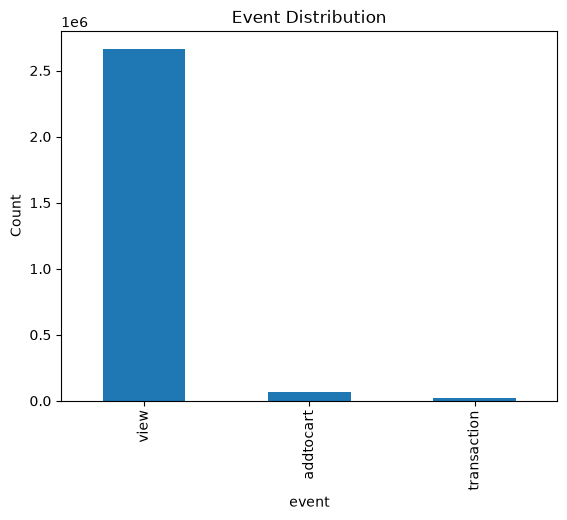

In [18]:
import matplotlib.pyplot as plt

events["event"].value_counts().plot(kind="bar")
plt.title("Event Distribution")
plt.ylabel("Count")
plt.show()

In [19]:
user_activity = events.groupby("visitorid").size()
print(user_activity.describe())

count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64


In [20]:
item_activity = events.groupby("itemid").size()
print(item_activity.describe())

count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64


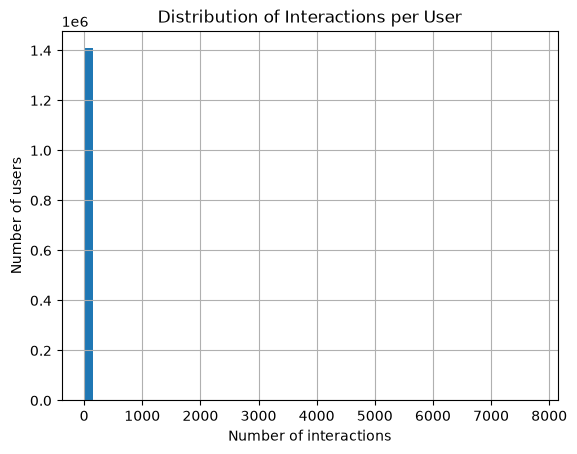

In [21]:
user_activity.hist(bins=50)
plt.title("Distribution of Interactions per User")
plt.xlabel("Number of interactions")
plt.ylabel("Number of users")
plt.show()

## 2. Filtering Sparse Users & Items

Most users/items have very few interactions (the long-tail problem). Models can't learn meaningful
embeddings from 1-2 data points, so we filter to users/items with at least 5 interactions.

In [22]:
user_counts = events["visitorid"].value_counts()
active_users = user_counts[user_counts >= 5].index

events_filtered = events[events["visitorid"].isin(active_users)]

item_counts = events_filtered["itemid"].value_counts()
active_items = item_counts[item_counts >= 5].index

events_filtered = events_filtered[events_filtered["itemid"].isin(active_items)]

print("Users:", events_filtered["visitorid"].nunique())
print("Products:", events_filtered["itemid"].nunique())
print("Interactions:", len(events_filtered))

Users: 80112
Products: 38977
Interactions: 833463


In [23]:
num_users = events_filtered["visitorid"].nunique()
num_products = events_filtered["itemid"].nunique()
num_interactions = len(events_filtered)

sparsity = (1 - (num_interactions / (num_users * num_products))) * 100
print(f"Sparsity after filtering: {sparsity:.4f}%")

Sparsity after filtering: 99.9733%


## 3. Baseline Model #1 — Popularity-Based Recommender

The simplest possible baseline: recommend whatever is most popular, weighted by interaction type
(a purchase signals much stronger interest than a view). Any real model should beat this.

In [24]:
weights = {
    "view": 1,
    "addtocart": 5,
    "transaction": 10
}

events_filtered["score"] = events_filtered["event"].map(weights)

popular_products = (
    events_filtered
    .groupby("itemid")["score"]
    .sum()
    .sort_values(ascending=False)
)

print(popular_products.head(10))

itemid
461686    3753
119736    1833
9877      1442
257040    1368
312728    1318
320130    1212
445351    1194
409804    1164
420960    1091
213834    1087
Name: score, dtype: int64


In [25]:
def recommend_popular(k=10):
    return popular_products.head(k)

recommend_popular()

itemid
461686    3753
119736    1833
9877      1442
257040    1368
312728    1318
320130    1212
445351    1194
409804    1164
420960    1091
213834    1087
Name: score, dtype: int64

## 4. Baseline Model #2 — Item-Based Collaborative Filtering

Build a user-item matrix and compute item-item cosine similarity. We restrict to the top 2,000 items
to keep this computationally feasible (a full matrix here would be too large for memory).

In [26]:
top_items = (
    events_filtered["itemid"]
    .value_counts()
    .head(2000)
    .index
)

events_cf = events_filtered[events_filtered["itemid"].isin(top_items)]

print(events_cf["visitorid"].nunique())
print(events_cf["itemid"].nunique())
print(len(events_cf))

43579
2000
249348


In [27]:
user_item_cf = events_cf.pivot_table(
    index="visitorid",
    columns="itemid",
    values="score",
    aggfunc="sum",
    fill_value=0
)

print(user_item_cf.shape)

(43579, 2000)


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(user_item_cf.T)
print(item_similarity.shape)

(2000, 2000)


In [29]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_cf.columns,
    columns=user_item_cf.columns
)

In [30]:
def recommend_similar(item_id, n=10):
    similar_items = (
        item_similarity_df[item_id]
        .sort_values(ascending=False)
        .iloc[1:n+1]  # skip itself (similarity = 1.0)
    )
    return similar_items

# Example: items similar to one of the most-viewed items
example_item = top_viewed.index[0]
recommend_similar(example_item)

itemid
61240     0.044482
137697    0.032309
290172    0.028384
62275     0.025256
438234    0.012692
358895    0.007657
93382     0.007510
389814    0.006318
267236    0.005304
186820    0.005260
Name: 187946, dtype: float64

This works for "people who liked this also liked..." style recommendations, but it doesn't scale well
(O(items²) similarity matrix) and can't produce personalized *user-level* rankings directly.
That's where matrix factorization comes in — it learns dense embeddings for every user and item.

## 5. Encoding IDs for PyTorch

Raw user/item IDs (e.g. `461686`) aren't usable as embedding indices directly — embeddings need
dense, zero-indexed integers. We build lookup dictionaries to map real IDs <-> contiguous indices.

In [31]:
user_ids = events_filtered["visitorid"].unique()
item_ids = events_filtered["itemid"].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids)}

idx_to_item = {idx: item_id for item_id, idx in item_to_idx.items()}

In [32]:
events_filtered["user_idx"] = events_filtered["visitorid"].map(user_to_idx)
events_filtered["item_idx"] = events_filtered["itemid"].map(item_to_idx)

events_filtered[["visitorid", "user_idx", "itemid", "item_idx", "score"]].head()

,visitorid,user_idx,itemid,item_idx,score
1,992329,0,248676,0,1
7,794181,1,439202,1,1
8,824915,2,428805,2,1
15,57036,3,334662,3,1
24,125625,4,17655,4,1


## 6. Matrix Factorization Model (PyTorch)

The model learns a dense embedding vector for every user and every item. A prediction is just the
dot product of a user's vector and an item's vector — high dot product = strong predicted preference.
This is the neural-network equivalent of classical matrix factorization (like SVD-based recommenders).

In [37]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

In [42]:
class MatrixFactorization(nn.Module):

    def __init__(self, num_users, num_items, embedding_dim=32):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

    def forward(self, user_ids, item_ids):
        user_vecs = self.user_embedding(user_ids)
        item_vecs = self.item_embedding(item_ids)
        # Dot product per (user, item) pair -> raw preference score (logit)
        preds = (user_vecs * item_vecs).sum(dim=1)
        return preds

## 7. Train/Test Split (Leave-Last-Interaction-Out)

For recommendation systems, a random split would leak information (a user's later behavior predicting
their earlier behavior). Instead, we use the standard approach: hold out each user's **most recent**
interaction as the test item, and train on everything before that.

We also require users to have at least 2 interactions, otherwise there's nothing left to train on
after holding one out.

In [33]:
user_counts = events_filtered.groupby("user_idx").size()
eligible_users = user_counts[user_counts >= 2].index

events_eval = events_filtered[events_filtered["user_idx"].isin(eligible_users)]
print("Eligible users:", events_eval["user_idx"].nunique())

Eligible users: 78512


In [34]:
events_sorted = events_eval.sort_values("timestamp")

test_idx = events_sorted.groupby("user_idx").tail(1).index

test_df = events_sorted.loc[test_idx]
train_df = events_sorted.drop(test_idx)

print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))
print("Train users:", train_df["user_idx"].nunique())
print("Test users:", test_df["user_idx"].nunique())

Train interactions: 753351
Test interactions: 78512
Train users: 78512
Test users: 78512


## 8. Implicit Feedback Dataset (Positive + Negative Sampling)

Our data is all *positive* signals (views/carts/purchases) — there's no such thing as a user explicitly
saying "I dislike this item." To train a binary classifier (did/didn't interact), we generate **negative
samples**: random items the user never interacted with, labeled `0`, paired against the real
interactions labeled `1`.

This turns recommendation into a binary classification problem, which is exactly why we use
`BCEWithLogitsLoss` (binary cross-entropy on raw logits) rather than `MSELoss` — the labels are 0/1,
not continuous ratings.

In [35]:
user_seen_items = (
    train_df
    .groupby("user_idx")["item_idx"]
    .apply(set)
    .to_dict()
)

In [38]:
class ImplicitDataset(Dataset):

    def __init__(self, train_df, num_items, user_seen_items, negatives_per_positive=1):
        self.samples = []
        all_items = set(range(num_items))

        for _, row in train_df.iterrows():
            user = row["user_idx"]
            pos_item = row["item_idx"]

            # Positive sample: a real interaction
            self.samples.append((user, pos_item, 1))

            seen = user_seen_items[user]

            # Negative samples: items this user never interacted with
            for _ in range(negatives_per_positive):
                neg_item = random.choice(list(all_items - seen))
                self.samples.append((user, neg_item, 0))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user, item, label = self.samples[idx]
        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(item, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32)
        )

In [39]:
num_users = events_filtered["user_idx"].nunique()
num_items = events_filtered["item_idx"].nunique()

implicit_dataset = ImplicitDataset(
    train_df,
    num_items,
    user_seen_items,
    negatives_per_positive=1
)

print("Total samples (positive + negative):", len(implicit_dataset))

Total samples (positive + negative): 1506702


In [40]:
implicit_loader = DataLoader(
    implicit_dataset,
    batch_size=1024,
    shuffle=True
)

## 9. Recommendation & Evaluation Function

Given a user, score every item by dot product with their learned embedding, mask out items they've
already seen (no point recommending something they already interacted with), and return the top-K.

We then evaluate using **Recall@10**: for each test user, did their real held-out item show up
in our top-10 recommendations? This is the standard metric for implicit-feedback recommenders.

In [45]:
def recommend_mf_eval(user_idx, k=10):
    model.eval()
    with torch.no_grad():
        user_vector = model.user_embedding.weight[user_idx]
        scores = torch.matmul(model.item_embedding.weight, user_vector)

        seen_items = user_seen_items.get(user_idx, set())
        scores[list(seen_items)] = -1e9  # mask out already-seen items

        top_items = torch.topk(scores, k).indices.numpy()
    return top_items

In [46]:
def evaluate_recall_at_10():
    model.eval()
    hits = 0
    with torch.no_grad():
        for _, row in test_df.iterrows():
            recs = recommend_mf_eval(row["user_idx"], k=10)
            if row["item_idx"] in recs:
                hits += 1
    return hits / len(test_df)

## 10. Training with Regularization (Avoiding Overfitting)

A key lesson from earlier iterations of this project: training loss alone is misleading. With enough
epochs, this model has more than enough capacity to **memorize** every training pair, driving loss
near zero — without learning anything that generalizes to new, unseen user-item pairs (which is what
Recall@10 on the test set actually measures).

To prevent this, we:
- Add `weight_decay` (L2 regularization) to the optimizer, which discourages embeddings from growing
  to extreme values just to fit training noise
- Check **Recall@10 every few epochs** (not just training loss) so we can catch the point where the
  model stops generalizing and starts memorizing — that peak is our best checkpoint

In [43]:
model = MatrixFactorization(num_users, num_items, embedding_dim=32)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

In [47]:
total_epochs = 20
check_every = 5

loss_history = []
recall_history = {}

for epoch in range(1, total_epochs + 1):
    model.train()
    total_loss = 0
    for users, items, labels in implicit_loader:
        optimizer.zero_grad()
        logits = model(users, items)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(implicit_loader)
    loss_history.append(avg_loss)

    if epoch % check_every == 0:
        recall = evaluate_recall_at_10()
        recall_history[epoch] = recall
        print(f"Epoch {epoch:2d} | Loss = {avg_loss:.4f} | Recall@10 = {recall:.6f}")
    else:
        print(f"Epoch {epoch:2d} | Loss = {avg_loss:.4f}")

Epoch  1 | Loss = 0.6247
Epoch  2 | Loss = 0.6357
Epoch  3 | Loss = 0.6407
Epoch  4 | Loss = 0.6399
Epoch  5 | Loss = 0.6369 | Recall@10 = 0.006585
Epoch  6 | Loss = 0.6340
Epoch  7 | Loss = 0.6316
Epoch  8 | Loss = 0.6299
Epoch  9 | Loss = 0.6285
Epoch 10 | Loss = 0.6275 | Recall@10 = 0.006496
Epoch 11 | Loss = 0.6267
Epoch 12 | Loss = 0.6261
Epoch 13 | Loss = 0.6257
Epoch 14 | Loss = 0.6253
Epoch 15 | Loss = 0.6249 | Recall@10 = 0.006700
Epoch 16 | Loss = 0.6247
Epoch 17 | Loss = 0.6244
Epoch 18 | Loss = 0.6242
Epoch 19 | Loss = 0.6240
Epoch 20 | Loss = 0.6239 | Recall@10 = 0.006458


In [ ]:
plt.plot(range(1, total_epochs + 1), loss_history, label="Train Loss")
plt.axhline(y=0.693, color='r', linestyle='--', label='Random baseline (ln 2)')
plt.xlabel("Epoch")
plt.ylabel("Avg BCE Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

print("Recall@10 by epoch checkpoint:")
for epoch, recall in recall_history.items():
    print(f"  Epoch {epoch}: {recall:.6f}")

**How to read this:** if Recall@10 rises and then starts *dropping* at later checkpoints while loss
keeps falling, that's overfitting in action — pick the epoch checkpoint with the **highest Recall@10**,
not the lowest loss, as your final model. If recall is still climbing at epoch 20, training longer
(or increasing `negatives_per_positive`, or trying a larger `embedding_dim`) is a reasonable next step.

## 11. Final Recommendations Demo

Sanity-check the trained model on a real, highly-active user — print what they've actually interacted
with vs. what the model recommends.

In [ ]:
user_strength = (
    train_df
    .groupby("user_idx")["score"]
    .sum()
    .sort_values(ascending=False)
)

top_user = user_strength.index[0]
print("Most active user_idx:", top_user)

print("\nTheir top historical interactions:")
print(
    train_df[train_df["user_idx"] == top_user]
    .sort_values("score", ascending=False)
    [["itemid", "event", "score"]]
    .head(10)
)

In [ ]:
recs = recommend_mf_eval(top_user, k=10)
recommended_item_ids = [idx_to_item[idx] for idx in recs]

print("Top 10 recommended item IDs for this user:")
print(recommended_item_ids)

## Summary

- Built and compared 3 approaches: popularity baseline, item-based CF, and learned matrix factorization
- Used leave-last-interaction-out splitting (the correct approach for sequential recommendation data)
- Trained on implicit feedback via negative sampling + binary cross-entropy
- Diagnosed and fixed overfitting using regularization + Recall@10 checkpointing, rather than trusting
  training loss alone

**Possible next steps:** try more negatives per positive, tune `embedding_dim`, add bias terms per
user/item, or move to a BPR (Bayesian Personalized Ranking) loss instead of pointwise BCE.

In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    model.state_dict(),
    "models/mf_bce_best.pth"
)

print("Model saved!")

In [ ]:
os.makedirs("data/processed", exist_ok=True)

events_filtered.to_pickle(
    "data/processed/events_filtered.pkl"
)

train_df.to_pickle(
    "data/processed/train_df.pkl"
)

test_df.to_pickle(
    "data/processed/test_df.pkl"
)

print("Datasets saved!")

In [ ]:
import pickle

with open("models/user_to_idx.pkl", "wb") as f:
    pickle.dump(user_to_idx, f)

with open("models/item_to_idx.pkl", "wb") as f:
    pickle.dump(item_to_idx, f)

with open("models/idx_to_item.pkl", "wb") as f:
    pickle.dump(idx_to_item, f)

print("Mappings saved!")

In [ ]:
import json

os.makedirs("results", exist_ok=True)

history = {
    "loss": loss_history,
    "recall": recall_history
}

with open("results/history.json", "w") as f:
    json.dump(history, f)

print("Training history saved!")

In [ ]:
exec(open("../save_model.py").read())